2026-04-09 16:19:32 - src.utils.file_handler - INFO - Loading CSV from: c:\Users\M.SAMLY\Desktop\student performance prediction\data\processed\train_test_split\test.csv
2026-04-09 16:19:32 - src.utils.file_handler - INFO - Successfully loaded 6519 rows and 22 columns
Test set: (6519, 21)
Loading models...
2026-04-09 16:19:32 - src.utils.file_handler - INFO - Loading model from: c:\Users\M.SAMLY\Desktop\student performance prediction\models\baseline\logistic_regression.pkl
2026-04-09 16:19:32 - src.utils.file_handler - INFO - Successfully loaded model from c:\Users\M.SAMLY\Desktop\student performance prediction\models\baseline\logistic_regression.pkl
2026-04-09 16:19:32 - src.utils.file_handler - INFO - Loading model from: c:\Users\M.SAMLY\Desktop\student performance prediction\models\improved\random_forest.pkl
2026-04-09 16:19:33 - src.utils.file_handler - INFO - Successfully loaded model from c:\Users\M.SAMLY\Desktop\student performance prediction\models\improved\random_forest.pkl
202

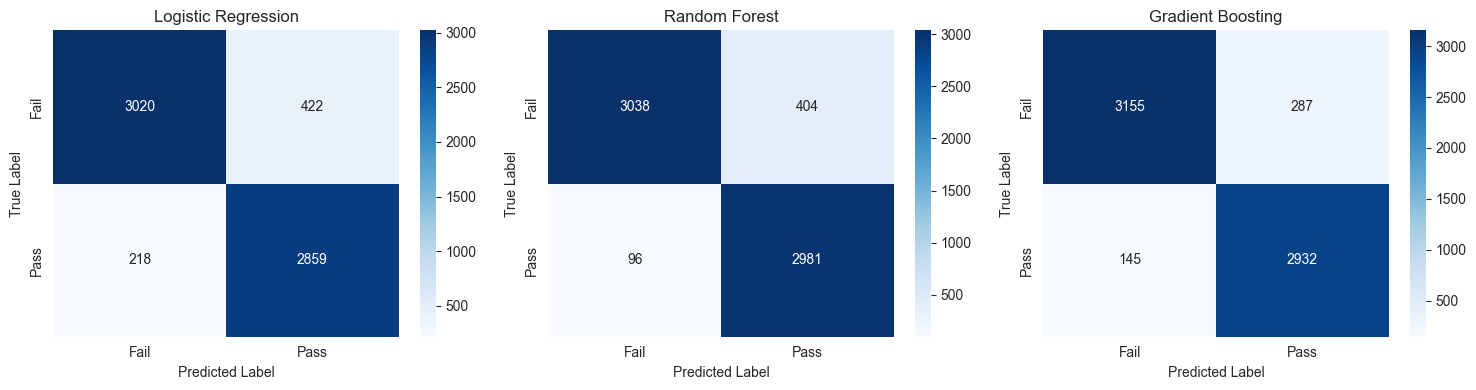

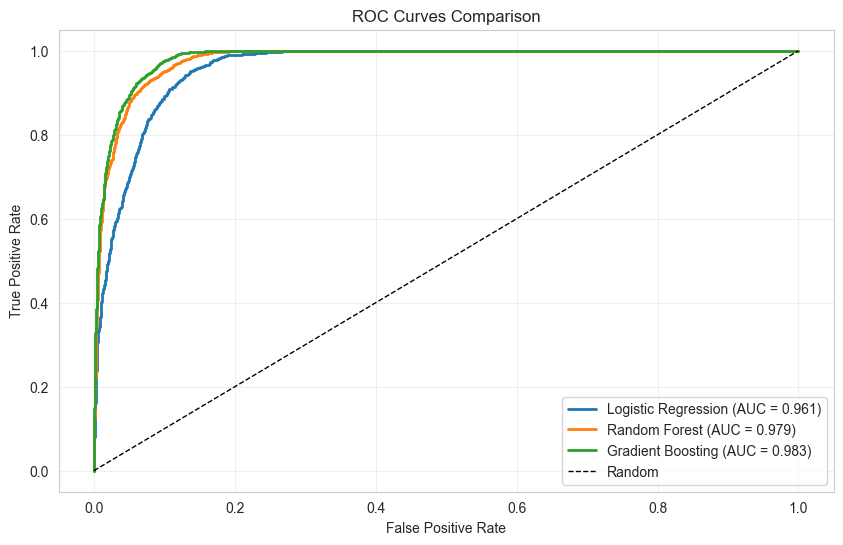

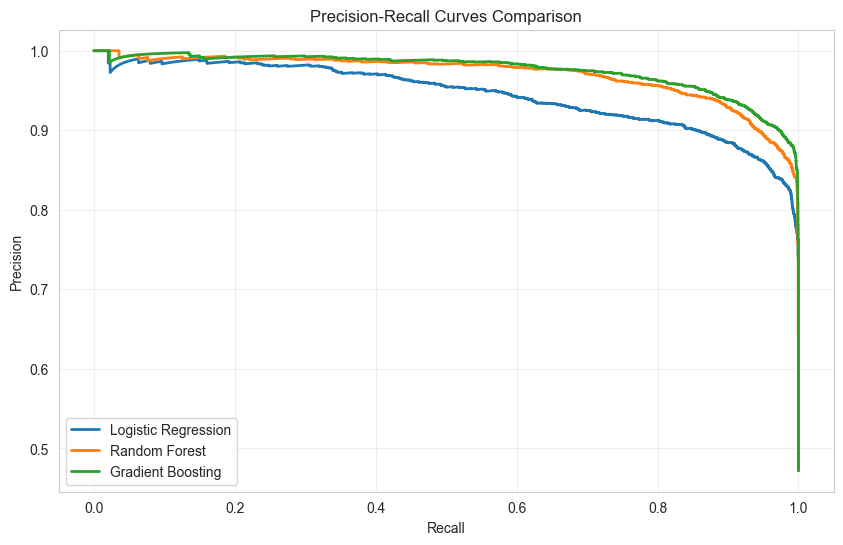


Logistic Regression - Classification Report
              precision    recall  f1-score   support

        Fail       0.93      0.88      0.90      3442
        Pass       0.87      0.93      0.90      3077

    accuracy                           0.90      6519
   macro avg       0.90      0.90      0.90      6519
weighted avg       0.90      0.90      0.90      6519


Random Forest - Classification Report
              precision    recall  f1-score   support

        Fail       0.97      0.88      0.92      3442
        Pass       0.88      0.97      0.92      3077

    accuracy                           0.92      6519
   macro avg       0.93      0.93      0.92      6519
weighted avg       0.93      0.92      0.92      6519


Gradient Boosting - Classification Report
              precision    recall  f1-score   support

        Fail       0.96      0.92      0.94      3442
        Pass       0.91      0.95      0.93      3077

    accuracy                           0.93      6519
 

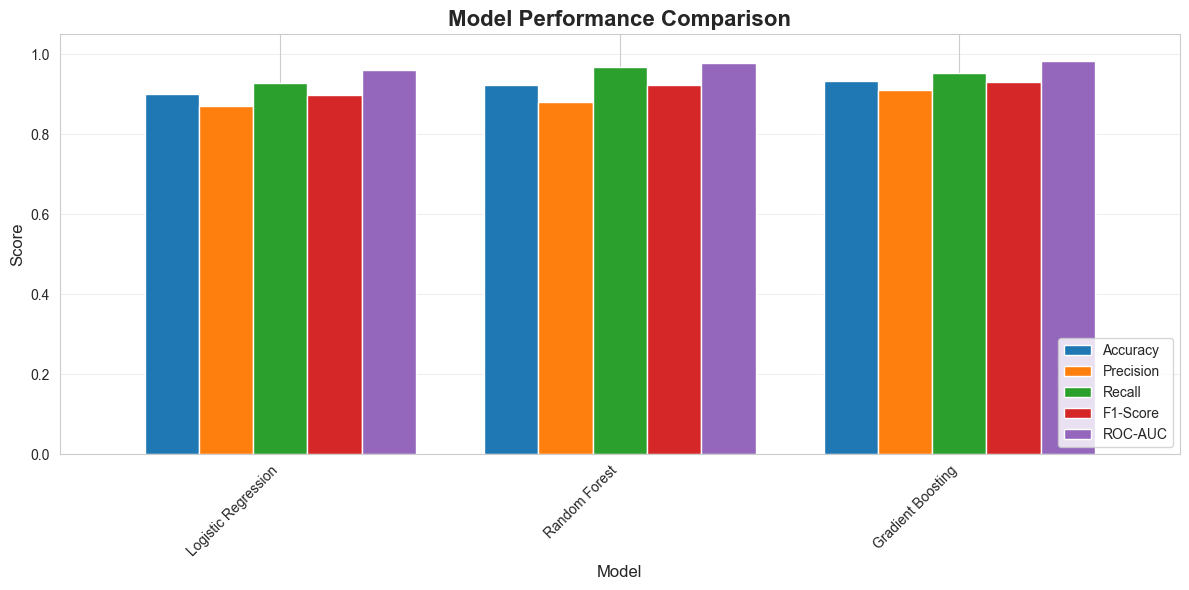


BEST MODEL
Model: Gradient Boosting
F1-Score: 0.9314

All Metrics:
Model        Gradient Boosting
Accuracy              0.933732
Precision             0.910842
Recall                0.952876
F1-Score              0.931385
ROC-AUC               0.982509


In [1]:
### notebooks/05_model_evaluation.ipynb
# Cell 1: Setup
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, 
    precision_recall_curve, roc_auc_score
)
from src.config import MODELS_DIR, PROCESSED_DATA_DIR, REPORTS_DIR
from src.utils.file_handler import load_csv, load_model, load_json

sns.set_style("whitegrid")

# Cell 2: Load Test Data
test_data = load_csv(PROCESSED_DATA_DIR / "train_test_split" / "test.csv")
X_test = test_data.drop('pass_fail', axis=1)
y_test = test_data['pass_fail']

print(f"Test set: {X_test.shape}")

# Cell 3: Load Models
print("Loading models...")

baseline_model = load_model(MODELS_DIR / "baseline" / "logistic_regression.pkl")
rf_model = load_model(MODELS_DIR / "improved" / "random_forest.pkl")
gb_model = load_model(MODELS_DIR / "improved" / "gradient_boosting.pkl")

print("Models loaded successfully!")

# Cell 4: Generate Predictions
print("Generating predictions...")

models = {
    'Logistic Regression': baseline_model,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model
}

predictions = {}
probabilities = {}

for name, model in models.items():
    predictions[name] = model.predict(X_test)
    probabilities[name] = model.predict_proba(X_test)[:, 1]

# Cell 5: Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Fail', 'Pass'],
                yticklabels=['Fail', 'Pass'])
    axes[idx].set_title(f'{name}')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Cell 6: ROC Curves
plt.figure(figsize=(10, 6))

for name, y_proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# Cell 7: Precision-Recall Curves
plt.figure(figsize=(10, 6))

for name, y_proba in probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    plt.plot(recall, precision, label=name, linewidth=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves Comparison')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

# Cell 8: Classification Reports
for name, y_pred in predictions.items():
    print(f"\n{'='*60}")
    print(f"{name} - Classification Report")
    print('='*60)
    print(classification_report(y_test, y_pred, target_names=['Fail', 'Pass']))

# Cell 9: Performance Metrics Table
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics_data = []

for name, y_pred in predictions.items():
    y_proba = probabilities[name]
    
    metrics_data.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

metrics_df = pd.DataFrame(metrics_data)
print("\nPerformance Metrics Summary:")
print(metrics_df.round(4))

# Cell 10: Visualize Metrics
metrics_plot = metrics_df.set_index('Model')

ax = metrics_plot.plot(kind='bar', figsize=(12, 6), width=0.8)
plt.title('Model Performance Comparison', fontsize=16, fontweight='bold')
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.ylim([0, 1.05])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Cell 11: Best Model
best_model_idx = metrics_df['F1-Score'].idxmax()
best_model_name = metrics_df.loc[best_model_idx, 'Model']
best_f1 = metrics_df.loc[best_model_idx, 'F1-Score']

print("\n" + "="*60)
print("BEST MODEL")
print("="*60)
print(f"Model: {best_model_name}")
print(f"F1-Score: {best_f1:.4f}")
print(f"\nAll Metrics:")
print(metrics_df.iloc[best_model_idx].to_string())